## ECG page lines with Hough transform

This notebook studies **straight-line detection** on a hard ECG photo.

### Hough idea
A line can be written in polar form:

$$\rho = x \cos(\theta) + y \sin(\theta)$$

Each edge pixel votes in the $(\rho, \theta)$ accumulator.
Peaks in that accumulator correspond to likely straight lines.

### Goal
Use one hard ECG image and see which page or grid lines Hough can recover before later page rectification.


## General parameters

These parameters control the preprocessing, edge map, and Hough detection.


In [41]:
# ---------------------------------
# Configuration
# ---------------------------------

MAX_DIM = 500

# Edge-map construction.
GAUSSIAN_SIGMA = 0.0
ENHANCEMENT_MODE = "none"
UNSHARP_RADIUS = 2.0
UNSHARP_AMOUNT = 1.5
OUTER_BLACK_BORDER = 0

# Canny parameters inside the shared energy builder.
CANNY_SIGMA = 2.0
CANNY_LOW_THRESHOLD = 0.10
CANNY_HIGH_THRESHOLD = 0.25

# Standard Hough transform.
THETA_STEP_DEGREES = round(MAX_DIM/500)
N_HOUGH_PEAKS = round(MAX_DIM/25)

# Probabilistic Hough segments.
HOUGH_THRESHOLD = round(MAX_DIM/25)
LINE_LENGTH = round(MAX_DIM/3)
LINE_GAP = round(MAX_DIM/50)


## Sample parameters

These select the ECG image used in this notebook.


In [42]:
selected_ecg_id = "11842146"
selected_scan_type = "0006"


In [43]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from skimage import morphology


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    candidates = [current, current.parent, current.parent.parent]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root for src imports.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.core import (
    EnergyConfig,
    EnhancementConfig,
    ProbabilisticHoughConfig,
    ResizeConfig,
    StandardHoughConfig,
)
from src.features import build_energy_image
from src.fitting import line_segment_from_rho_theta, run_probabilistic_hough, run_standard_hough
from src.io import find_sample_path, load_sample_rgb_image, rgb_to_gray_unit
from src.preprocessing import resize_keep_aspect


## Step 1 - Load the ECG image

We start from one hard ECG photo.


ECG ID: 11842146
Scan type: 0006
Path: D:\Dev\ML\workspace\kaggle_challenges\Physionet_ECG_challenge\data\sample\11842146\11842146-0006.png
Original shape: (4000, 3000, 3)


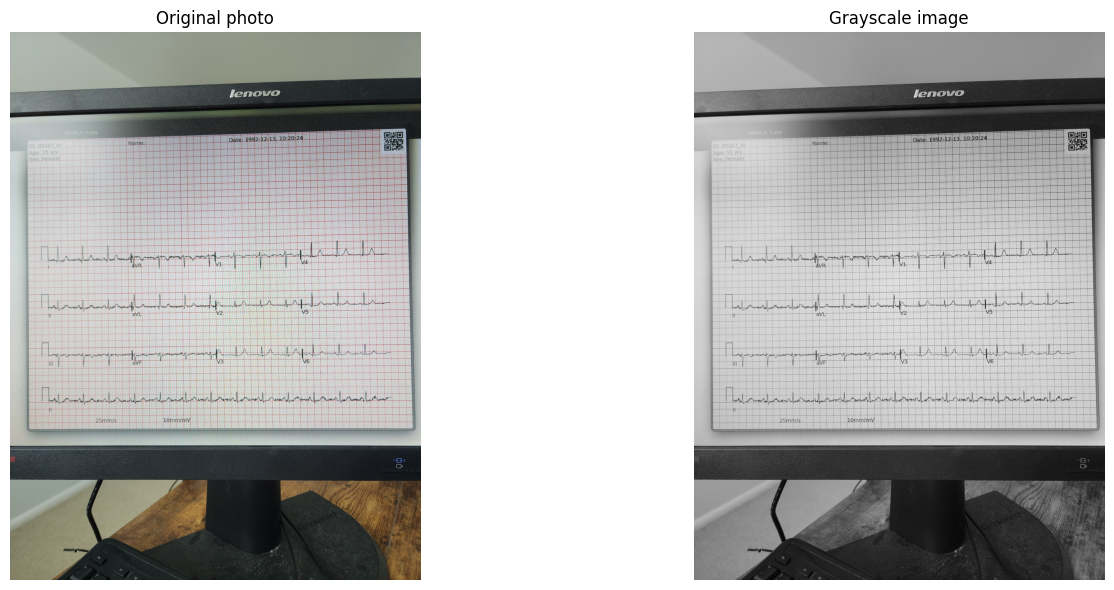

In [44]:
sample_root = find_sample_path(PROJECT_ROOT)

resize_cfg = ResizeConfig(max_dim=MAX_DIM)
enhancement_cfg = EnhancementConfig(
    mode=ENHANCEMENT_MODE,
    unsharp_radius=UNSHARP_RADIUS,
    unsharp_amount=UNSHARP_AMOUNT,
)
energy_cfg = EnergyConfig(
    mode="canny",
    gaussian_sigma=GAUSSIAN_SIGMA,
    canny_sigma=CANNY_SIGMA,
    canny_low_threshold=CANNY_LOW_THRESHOLD,
    canny_high_threshold=CANNY_HIGH_THRESHOLD,
    post_brighten_mode="none",
    post_brighten_gamma=1.0,
    outer_black_border=OUTER_BLACK_BORDER,
)
standard_hough_cfg = StandardHoughConfig(
    theta_step_degrees=THETA_STEP_DEGREES,
    n_peaks=N_HOUGH_PEAKS,
)
prob_hough_cfg = ProbabilisticHoughConfig(
    theta_step_degrees=THETA_STEP_DEGREES,
    threshold=HOUGH_THRESHOLD,
    line_length=LINE_LENGTH,
    line_gap=LINE_GAP,
)

rgb_img, image_path = load_sample_rgb_image(sample_root, selected_ecg_id, selected_scan_type)
gray_img = rgb_to_gray_unit(rgb_img)

print("ECG ID:", selected_ecg_id)
print("Scan type:", selected_scan_type)
print("Path:", image_path)
print("Original shape:", rgb_img.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(rgb_img)
axes[0].set_title("Original photo")
axes[0].axis("off")

axes[1].imshow(gray_img, cmap="gray")
axes[1].set_title("Grayscale image")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Step 2 - Resize and build the edge map

We resize the image and build the Canny edge map with the shared `src` energy builder.


Resize scale: 0.1250
Resized shape: (500, 375)
Enhancement mode: none
Gaussian sigma: 0.00
Canny sigma: 2.00
Canny low threshold: 0.10
Canny high threshold: 0.25
Outer black border: 0


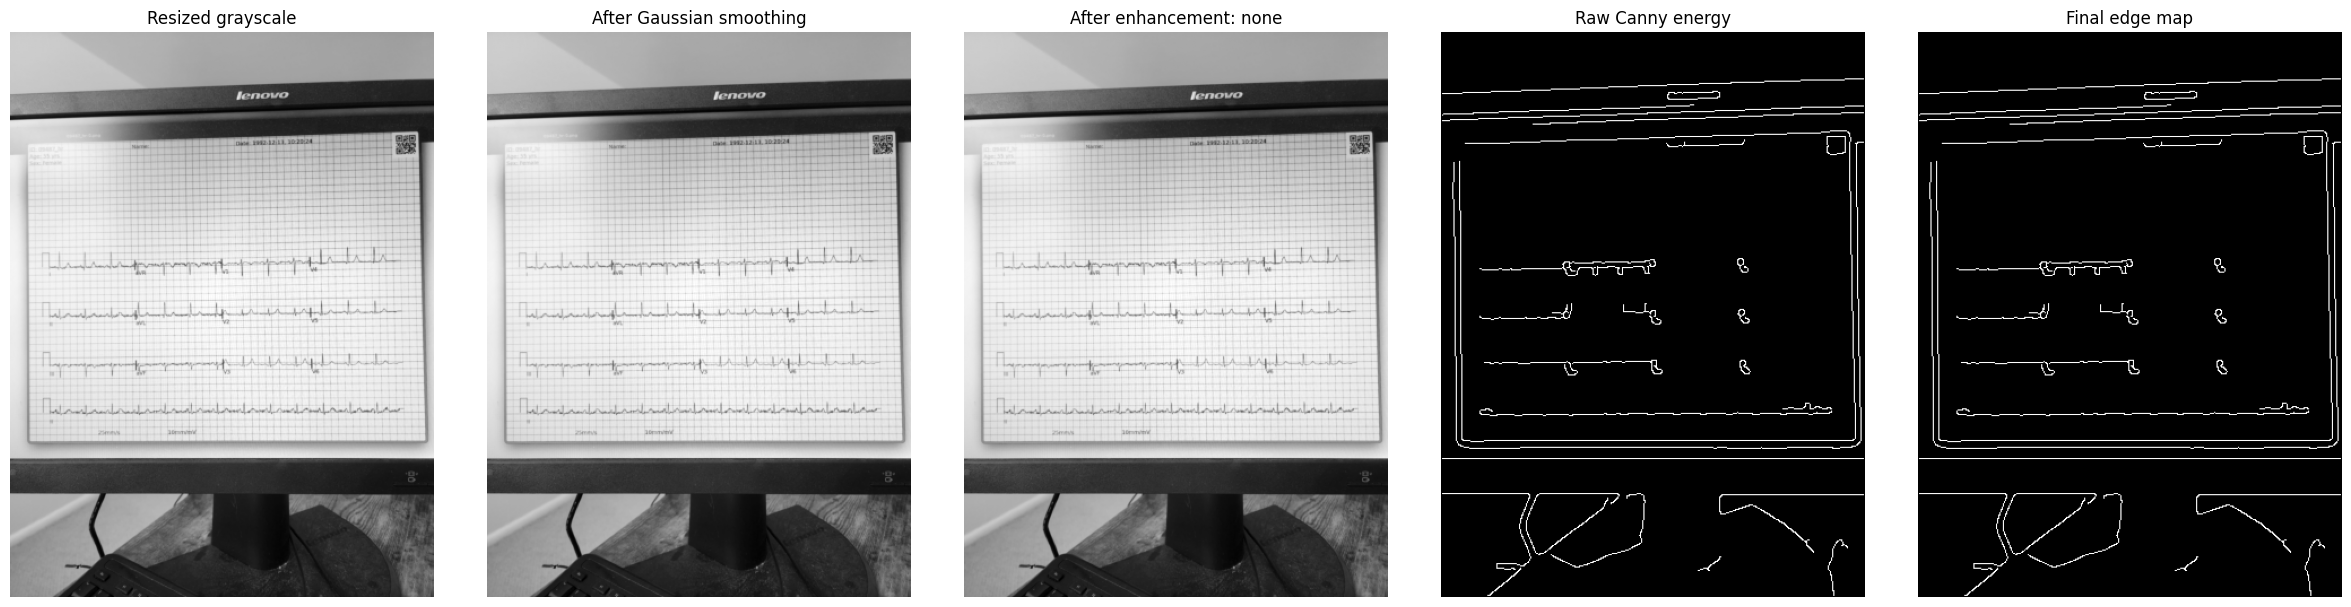

In [45]:
resized_gray, resize_scale = resize_keep_aspect(gray_img, resize_cfg.max_dim)
smoothed_gray, enhanced_gray, raw_energy_image, final_energy_image = build_energy_image(
    resized_gray,
    enhancement_cfg,
    energy_cfg,
)
edges = final_energy_image > 0

print(f"Resize scale: {resize_scale:.4f}")
print("Resized shape:", resized_gray.shape)
print("Enhancement mode:", enhancement_cfg.mode)
print(f"Gaussian sigma: {energy_cfg.gaussian_sigma:.2f}")
print(f"Canny sigma: {energy_cfg.canny_sigma:.2f}")
print(f"Canny low threshold: {energy_cfg.canny_low_threshold:.2f}")
print(f"Canny high threshold: {energy_cfg.canny_high_threshold:.2f}")
print("Outer black border:", energy_cfg.outer_black_border)

fig, axes = plt.subplots(1, 5, figsize=(24, 6))
axes[0].imshow(resized_gray, cmap="gray")
axes[0].set_title("Resized grayscale")
axes[0].axis("off")

axes[1].imshow(smoothed_gray, cmap="gray")
axes[1].set_title("After Gaussian smoothing")
axes[1].axis("off")

axes[2].imshow(enhanced_gray, cmap="gray")
axes[2].set_title(f"After enhancement: {enhancement_cfg.mode}")
axes[2].axis("off")

axes[3].imshow(raw_energy_image, cmap="gray")
axes[3].set_title("Raw Canny energy")
axes[3].axis("off")

axes[4].imshow(edges, cmap="gray")
axes[4].set_title("Final edge map")
axes[4].axis("off")

plt.tight_layout()
plt.show()


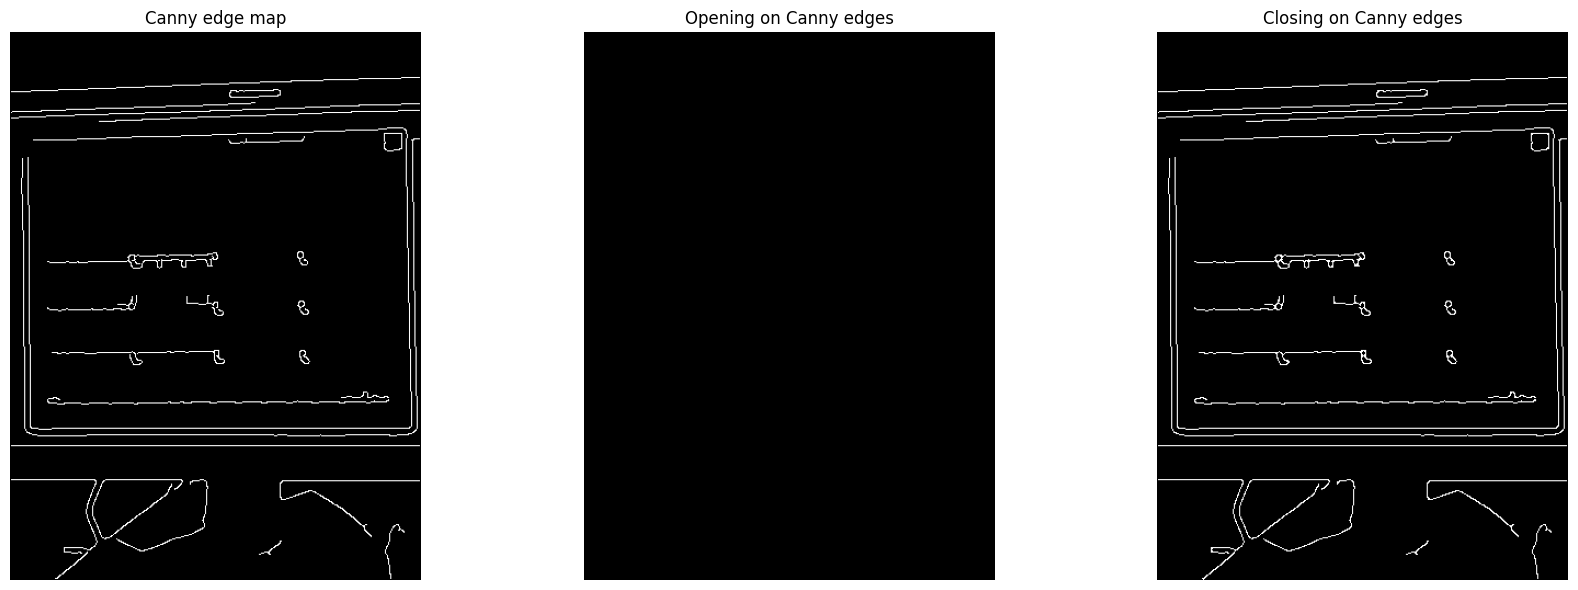

In [46]:
morphology_footprint = morphology.disk(1)
opened_edges_image = morphology.binary_opening(edges, morphology_footprint)
closed_edges_image = morphology.binary_closing(edges, morphology_footprint)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Canny edge map")
axes[0].axis("off")

axes[1].imshow(opened_edges_image, cmap="gray")
axes[1].set_title("Opening on Canny edges")
axes[1].axis("off")

axes[2].imshow(closed_edges_image, cmap="gray")
axes[2].set_title("Closing on Canny edges")
axes[2].axis("off")

plt.tight_layout()
plt.show()
edges=closed_edges_image

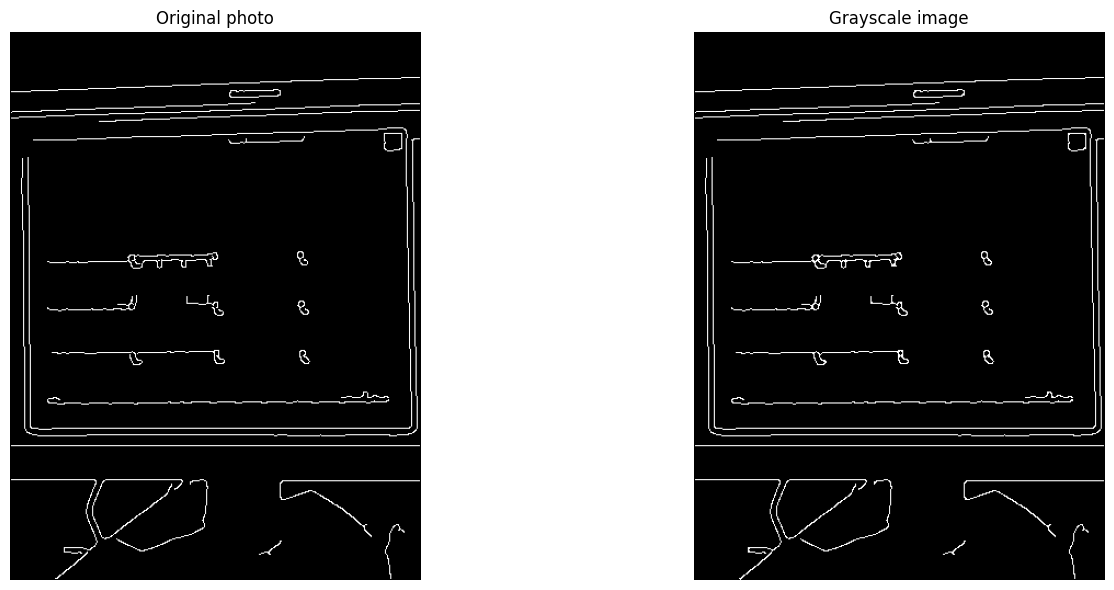

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(raw_energy_image, cmap="gray")
axes[0].set_title("Original photo")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Grayscale image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Step 3 - Standard Hough transform and peaks

We compute the accumulator and select the strongest peaks. Then we draw the corresponding infinite lines on the image.


Accumulator shape: (1251, 180)
Detected Hough peaks: 6
Segment : ((0.0, 377.0), (374.0, 377.0))
Segment : ((0.0, 361.0), (374.0, 361.0))
Segment : ((0.0, 78.0475444553081), (374.0, 64.9871766653944))
Segment : ((0.0, 54.032915392136374), (374.0, 40.97254760222268))
Segment : ((0.0, 100.06095442988217), (374.0, 87.00058663996849))
Segment : ((359.05468576776286, 0.0), (367.7647631669434, 499.0))


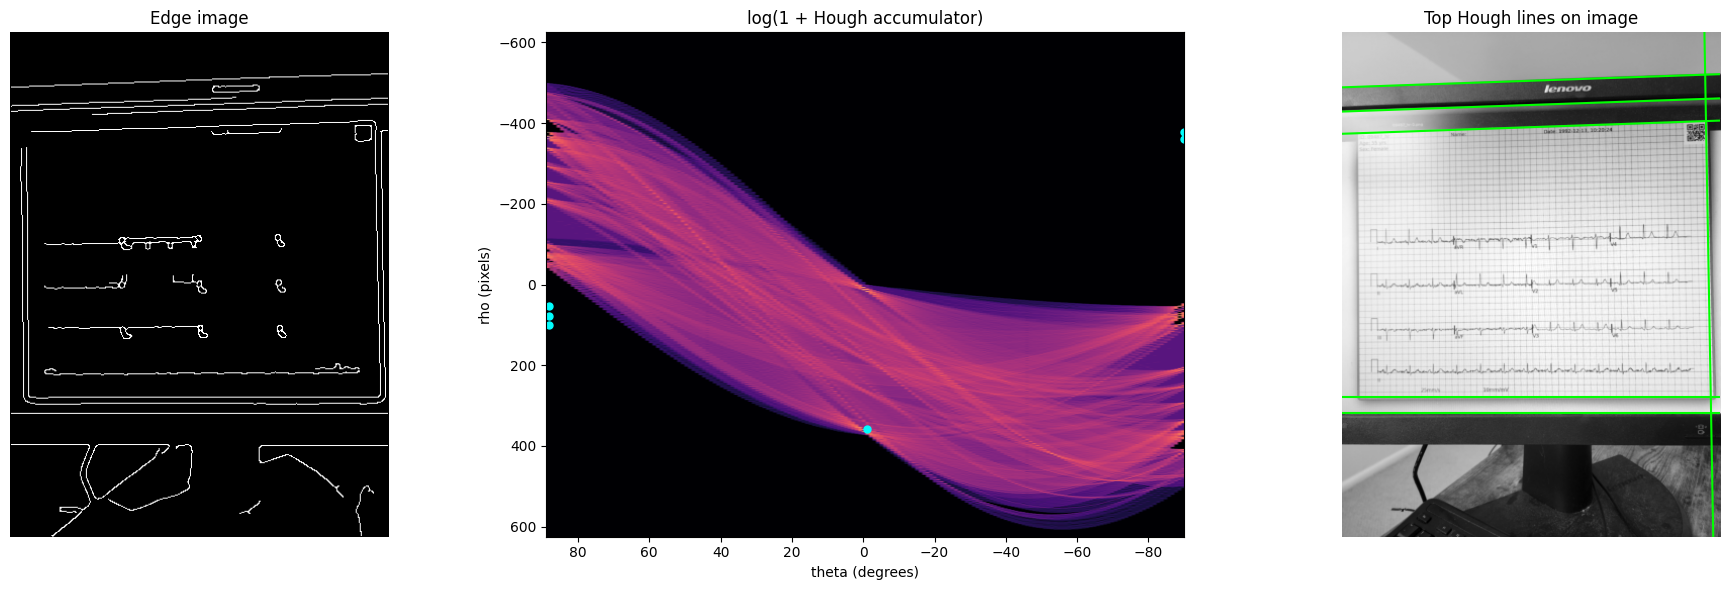

In [48]:
standard_hough_result = run_standard_hough(edges, standard_hough_cfg)

print("Accumulator shape:", standard_hough_result.accumulator.shape)
print("Detected Hough peaks:", len(standard_hough_result.peak_angles))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Edge image")
axes[0].axis("off")

axes[1].imshow(
    np.log1p(standard_hough_result.accumulator),
    cmap="magma",
    aspect="auto",
    extent=[
        np.rad2deg(standard_hough_result.angles[-1]),
        np.rad2deg(standard_hough_result.angles[0]),
        standard_hough_result.distances[-1],
        standard_hough_result.distances[0],
    ],
)
axes[1].set_title("log(1 + Hough accumulator)")
axes[1].set_xlabel("theta (degrees)")
axes[1].set_ylabel("rho (pixels)")
axes[1].scatter(np.rad2deg(standard_hough_result.peak_angles), standard_hough_result.peak_distances, color="cyan", s=25)

axes[2].imshow(resized_gray, cmap="gray")
for angle, dist in zip(standard_hough_result.peak_angles, standard_hough_result.peak_distances):
    segment = line_segment_from_rho_theta(float(dist), float(angle), resized_gray.shape)
    print(f"Segment : {segment}")
    if segment is None:
        continue
    (x0, y0), (x1, y1) = segment
    axes[2].plot([x0, x1], [y0, y1], color="lime", linewidth=1.5)
axes[2].set_title("Top Hough lines on image")
axes[2].axis("off")

plt.tight_layout()
plt.show()


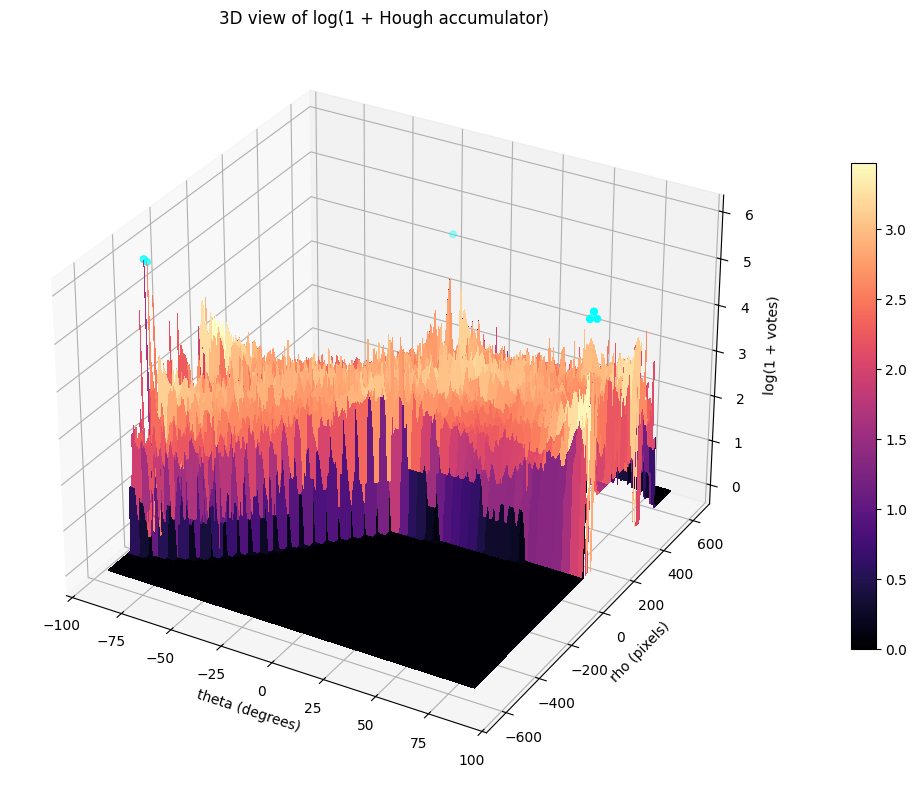

In [49]:
rho_step = max(1, standard_hough_result.accumulator.shape[0] // 300)
theta_step = max(1, standard_hough_result.accumulator.shape[1] // 180)

accumulator_3d = np.log1p(standard_hough_result.accumulator[::rho_step, ::theta_step])
theta_deg_3d = np.rad2deg(standard_hough_result.angles[::theta_step])
rho_3d = standard_hough_result.distances[::rho_step]
theta_grid_3d, rho_grid_3d = np.meshgrid(theta_deg_3d, rho_3d)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(
    theta_grid_3d,
    rho_grid_3d,
    accumulator_3d,
    cmap="magma",
    linewidth=0,
    antialiased=False,
)
ax.scatter(
    np.rad2deg(standard_hough_result.peak_angles),
    standard_hough_result.peak_distances,
    np.log1p(standard_hough_result.peak_accumulator),
    color="cyan",
    s=24,
)
ax.set_title("3D view of log(1 + Hough accumulator)")
ax.set_xlabel("theta (degrees)")
ax.set_ylabel("rho (pixels)")
ax.set_zlabel("log(1 + votes)")
fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.08)
plt.tight_layout()
plt.show()


## Step 4 - Probabilistic Hough line segments

The standard transform gives infinite lines. The probabilistic version gives visible line segments, which is often easier to inspect on the ECG page.


Detected line segments: 12


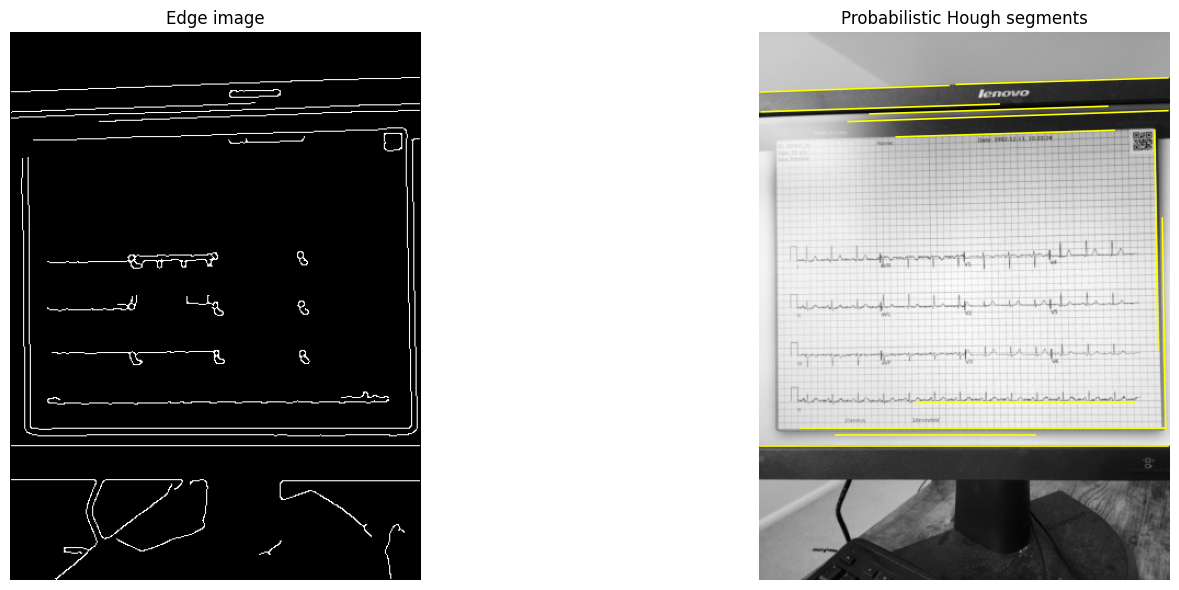

In [50]:
prob_hough_result = run_probabilistic_hough(edges, prob_hough_cfg)

print("Detected line segments:", len(prob_hough_result.segments))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(edges, cmap="gray")
axes[0].set_title("Edge image")
axes[0].axis("off")

axes[1].imshow(resized_gray, cmap="gray")
for (x0, y0), (x1, y1) in prob_hough_result.segments:
    axes[1].plot([x0, x1], [y0, y1], color="yellow", linewidth=1.2)
axes[1].set_title("Probabilistic Hough segments")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Conclusion

This notebook now reuses the shared `src` methods for the edge map and for both Hough variants.

The standard Hough transform is useful to see the dominant line directions and the accumulator peaks.
The probabilistic version is useful to see the actual line segments on the page.

So compared with active contour:
- active contour gives a flexible page boundary
- Hough transform gives straight-line structure

This is the natural next step before page corners and rectification.
